<a href="https://colab.research.google.com/github/Bhagya028/EDUFYI/blob/main/CNN_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:

# # Install required packages
# !pip install tensorflow
# !pip install scikit-learn
# !pip install keras

# Note: In newer TensorFlow/Keras versions, ImageDataGenerator might be imported from tensorflow.keras.preprocessing.image.
# If you encounter an ImportError, you might need to change the import in cell JxKtjla7QrvF to:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img


In [32]:
import pandas as pd
import numpy as np
import itertools
import keras
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dropout, Flatten, Dense,BatchNormalization,Conv2D,MaxPool2D, LeakyReLU
from tensorflow.keras import applications
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
import math
import datetime
import time

In [33]:
img_width, img_height = 128,128
# loading up our datasets

train_data_dir = r'/content/drive/MyDrive/Vani-dev/xray_dataset_covid19/train'
#validation_data_dir = ‘data/validation’
test_data_dir = r'/content/drive/MyDrive/Vani-dev/xray_dataset_covid19/test'

In [34]:
# number of epochs to train top model
epochs = 7 #this has been changed after multiple model run
# batch size used by flow_from_directory and predict_generator
batch_size = 32

# Image Augmentation

In [35]:
def get_generator(path):
    generator = datagen.flow_from_directory(
        path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False)

    nb_samples = len(generator.filenames)
    num_classes = len(generator.class_indices)

    predict_size_train = int(math.ceil(nb_samples / batch_size))
    # get the class labels for the training data, in the original order
    labels = generator.classes

    # convert the training labels to categorical vectors
    labels = to_categorical(labels, num_classes=num_classes)
    return (generator,nb_samples,predict_size_train,labels)

In [36]:
datagen = ImageDataGenerator(rescale=1. / 255)

In [37]:
generator_train,nb_train_samples,predict_size_train,train_labels = get_generator(train_data_dir)
generator_test,nb_test_samples,predict_size_test,test_labels    = get_generator(test_data_dir)
num_classes = 3
class_labels=list(generator_train.class_indices.keys())

Found 222 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


# Apply Pre-trained Model

In [38]:
def apply_pretrainedModel(pretrained_model,generator,predict_size):
    return pretrained_model.predict(generator, steps=predict_size)

# Apply transfer Learning

In [39]:
def cnn_after_pretrainedModel(input_shape):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(128, activation=LeakyReLU(alpha=0.3)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation=LeakyReLU(alpha=0.3)))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy',
       optimizer=optimizers.Adam(learning_rate=1e-4),
       metrics=['acc'])
    return model;

In [40]:
def transfer_learning(pretrained_model,epochs=25):
    #Appling Pretrained Model to train and test datasets
    train_data = apply_pretrainedModel(pretrained_model,generator_train,predict_size_train)
    test_data  = apply_pretrainedModel(pretrained_model,generator_test,predict_size_test)
    model      = cnn_after_pretrainedModel(train_data.shape[1:])
    history = model.fit(train_data, train_labels,
       epochs=epochs,
       batch_size=batch_size,
       validation_data=(test_data, test_labels))
    (eval_loss, eval_accuracy) = model.evaluate(
        test_data, test_labels, batch_size=batch_size,     verbose=1)
    print("[INFO] accuracy: {:.2f}%".format(eval_accuracy * 100))
    print("[INFO] Loss: {}".format(eval_loss))

    return train_data,test_data,model,history,eval_accuracy

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
def plot_graphs(history):
    #Graphing our training and validation
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))
    plt.plot(epochs, acc, 'r', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend()
    plt.figure()
    plt.plot(epochs, loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend()
    plt.show()

# Build Model  VGG

In [43]:
#Loading Pre-trained Model
model_name="VGG"
pretrained_model_vgg  = applications.VGG16(include_top=False, weights='imagenet')
train_data,test_data,model_vgg,history_vgg,acc_vgg = transfer_learning(pretrained_model_vgg)
print()

7/7 ━━━━━━━━━━━━━━━━━━━━ 60s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - acc: 0.3829 - loss: 1.2272 - val_acc: 0.6667 - val_loss: 0.8714
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - acc: 0.4910 - loss: 0.9530 - val_acc: 0.7333 - val_loss: 0.7174
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.6486 - loss: 0.7686 - val_acc: 0.8667 - val_loss: 0.6058
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.7928 - loss: 0.6062 - val_acc: 0.9167 - val_loss: 0.4861
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.8243 - loss: 0.4793 - val_acc: 0.9333 - val_loss: 0.3602
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.8784 - loss: 0.4266 - val_acc: 0.9500 - val_loss: 0.3091
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - acc: 0.9234 - loss: 0.3200 - val_acc: 0.9500 - val_loss: 0.2517
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9099 - loss: 0.2843 - val_acc: 0.9167 - val_loss: 0.2465
Epoch 9/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - acc: 0.9324 - loss: 0.2730 - val_acc: 0.

# Visualise VGG training and testing

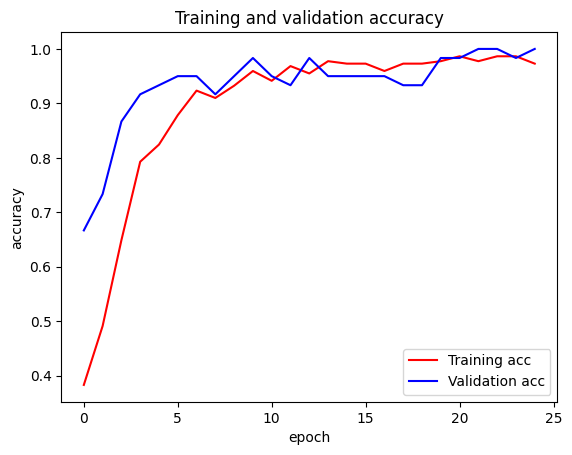

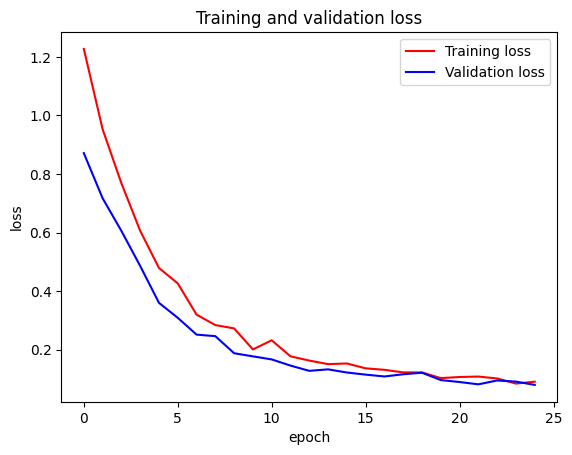

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [44]:
plot_graphs(history_vgg)
preds=np.round(model_vgg.predict(test_data),0)

# Performance Metrics

In [45]:
classify_matrics_vgg=metrics.classification_report(test_labels,preds,target_names=class_labels)
print(classify_matrics_vgg)

              precision    recall  f1-score   support

       COVID       1.00      1.00      1.00        20
      NORMAL       1.00      1.00      1.00        20
   PNEUMONIA       1.00      1.00      1.00        20

   micro avg       1.00      1.00      1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60
 samples avg       1.00      1.00      1.00        60



## Applying GOOGLE NET

In [46]:
#Loading Pre-trained Model
model_name="INCEPTION NET"
pretrained_model_googleNet  = applications.InceptionV3(include_top=False, weights='imagenet')
train_data,test_data,model_googleNet,history_googleNet,acc_googleNet = transfer_learning(pretrained_model_googleNet)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


6/7 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 738ms/step
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - acc: 0.3649 - loss: 2.4464 - val_acc: 0.6667 - val_loss: 0.7283
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.5631 - loss: 1.1134 - val_acc: 0.8833 - val_loss: 0.3952
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.7027 - loss: 1.0194 - val_acc: 0.8833 - val_loss: 0.3612
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc: 0.7387 - loss: 0.6348 - val_acc: 0.8833 - val_loss: 0.3617
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - acc: 0.8108 - loss: 0.5171 - val_acc: 0.8833 - val_loss: 0.3477
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.8468 - loss: 0.4135 - val_acc: 0.8833 - val_loss: 0.3979
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.8514 - loss: 0.4061 - val_acc: 0.8833 - val_loss: 0.3176
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - acc: 0.9099 - loss: 0.2521 - val_acc: 0.9000 - val_loss: 0.3339
Epoch 9/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.8649 - loss: 0.4058 - val_acc: 0.

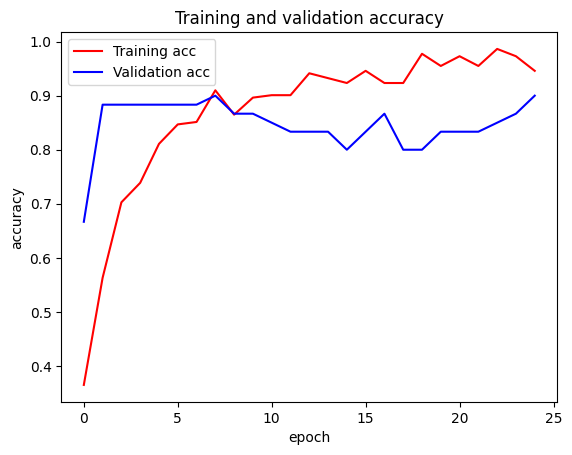

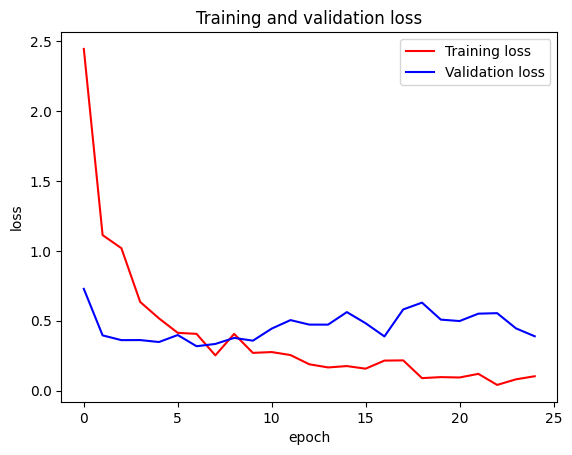

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


In [47]:
plot_graphs(history_googleNet)
preds=np.round(model_googleNet.predict(test_data),0)

In [48]:
classify_matrics_googleNet=metrics.classification_report(test_labels,preds,target_names=class_labels)
print(classify_matrics_googleNet)

              precision    recall  f1-score   support

       COVID       0.95      0.90      0.92        20
      NORMAL       0.85      0.85      0.85        20
   PNEUMONIA       0.90      0.95      0.93        20

   micro avg       0.90      0.90      0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60
 samples avg       0.90      0.90      0.90        60



# ResNet

In [49]:
#Loading Pre-trained Model
model_name="INCEPTION NET"
pretrained_model_resNet  = applications.ResNet50(include_top=False, weights='imagenet')
train_data,test_data,model_resNet,history_resNet,acc_resNet= transfer_learning(pretrained_model_resNet)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - acc: 0.3108 - loss: 1.2572 - val_acc: 0.3333 - val_loss: 1.0986
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - acc: 0.2928 - loss: 1.1813 - val_acc: 0.3333 - val_loss: 1.0822
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - acc: 0.4099 - loss: 1.0918 - val_acc: 0.3500 - val_loss: 1.0678
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - acc: 0.3514 - loss: 1.1239 - val_acc: 0.6333 - val_loss: 1.0498
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - acc: 0.3108 - loss: 1.1534 - val_acc: 0.3833 - val_loss: 1.0495
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - acc: 0.3964 - loss: 1.0979 - val_acc: 0.7000 - val_loss: 1.0433
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - acc: 0.4324 - loss: 1.0517 - val_acc: 0.7167 - val_loss: 1.0216
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - acc: 0.5090 - loss: 1.0249 - val_acc: 0.7000 - val_loss: 1.0103
Epoch 9/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - acc: 0.4955 - loss: 1.0208 - val_a

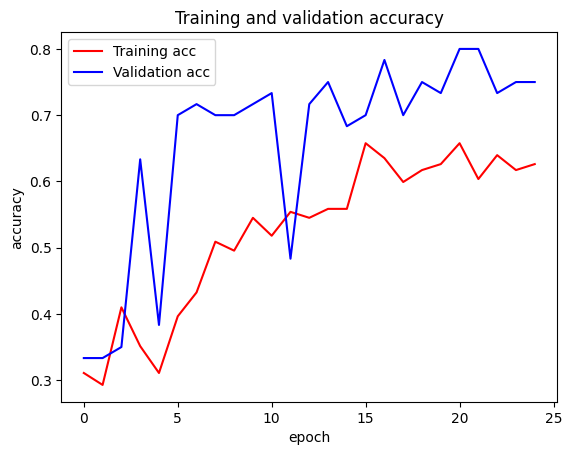

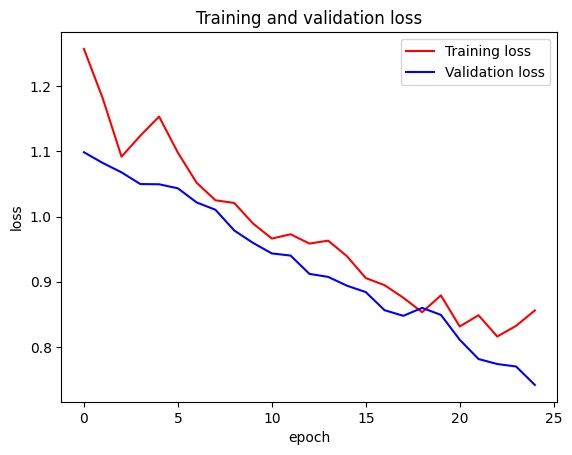

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


In [50]:
plot_graphs(history_resNet)
preds=np.round(model_resNet.predict(test_data),0)

In [51]:
classify_matrics_resNet=metrics.classification_report(test_labels,preds,target_names=class_labels)
print(classify_matrics_resNet)

              precision    recall  f1-score   support

       COVID       1.00      0.95      0.97        20
      NORMAL       0.65      0.65      0.65        20
   PNEUMONIA       0.00      0.00      0.00        20

   micro avg       0.82      0.53      0.65        60
   macro avg       0.55      0.53      0.54        60
weighted avg       0.55      0.53      0.54        60
 samples avg       0.53      0.53      0.53        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Comparing Models

In [52]:
print("Accuracies of Models")
print("VGG\t\t",acc_vgg)
print("Google Net\t",acc_googleNet)
print("ResNet\t\t",acc_resNet)


Accuracies of Models
VGG		 1.0
Google Net	 0.8999999761581421
ResNet		 0.75


# Testing a Single Image

In [53]:
def read_image(file_path):
   print("[INFO] loading and preprocessing image…")
   image = load_img(file_path, target_size=(img_width, img_height))
   image = img_to_array(image)
   image = np.expand_dims(image, axis=0)
   image /= 255.
   return image

[INFO] loading and preprocessing image…
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
ID: 0, Label: COVID 100.0%
ID: 1, Label: NORMAL 0.0%
ID: 2, Label: PNEUMONIA 0.0%
Final Decision:
.
..
...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
ID: 0, Label: COVID


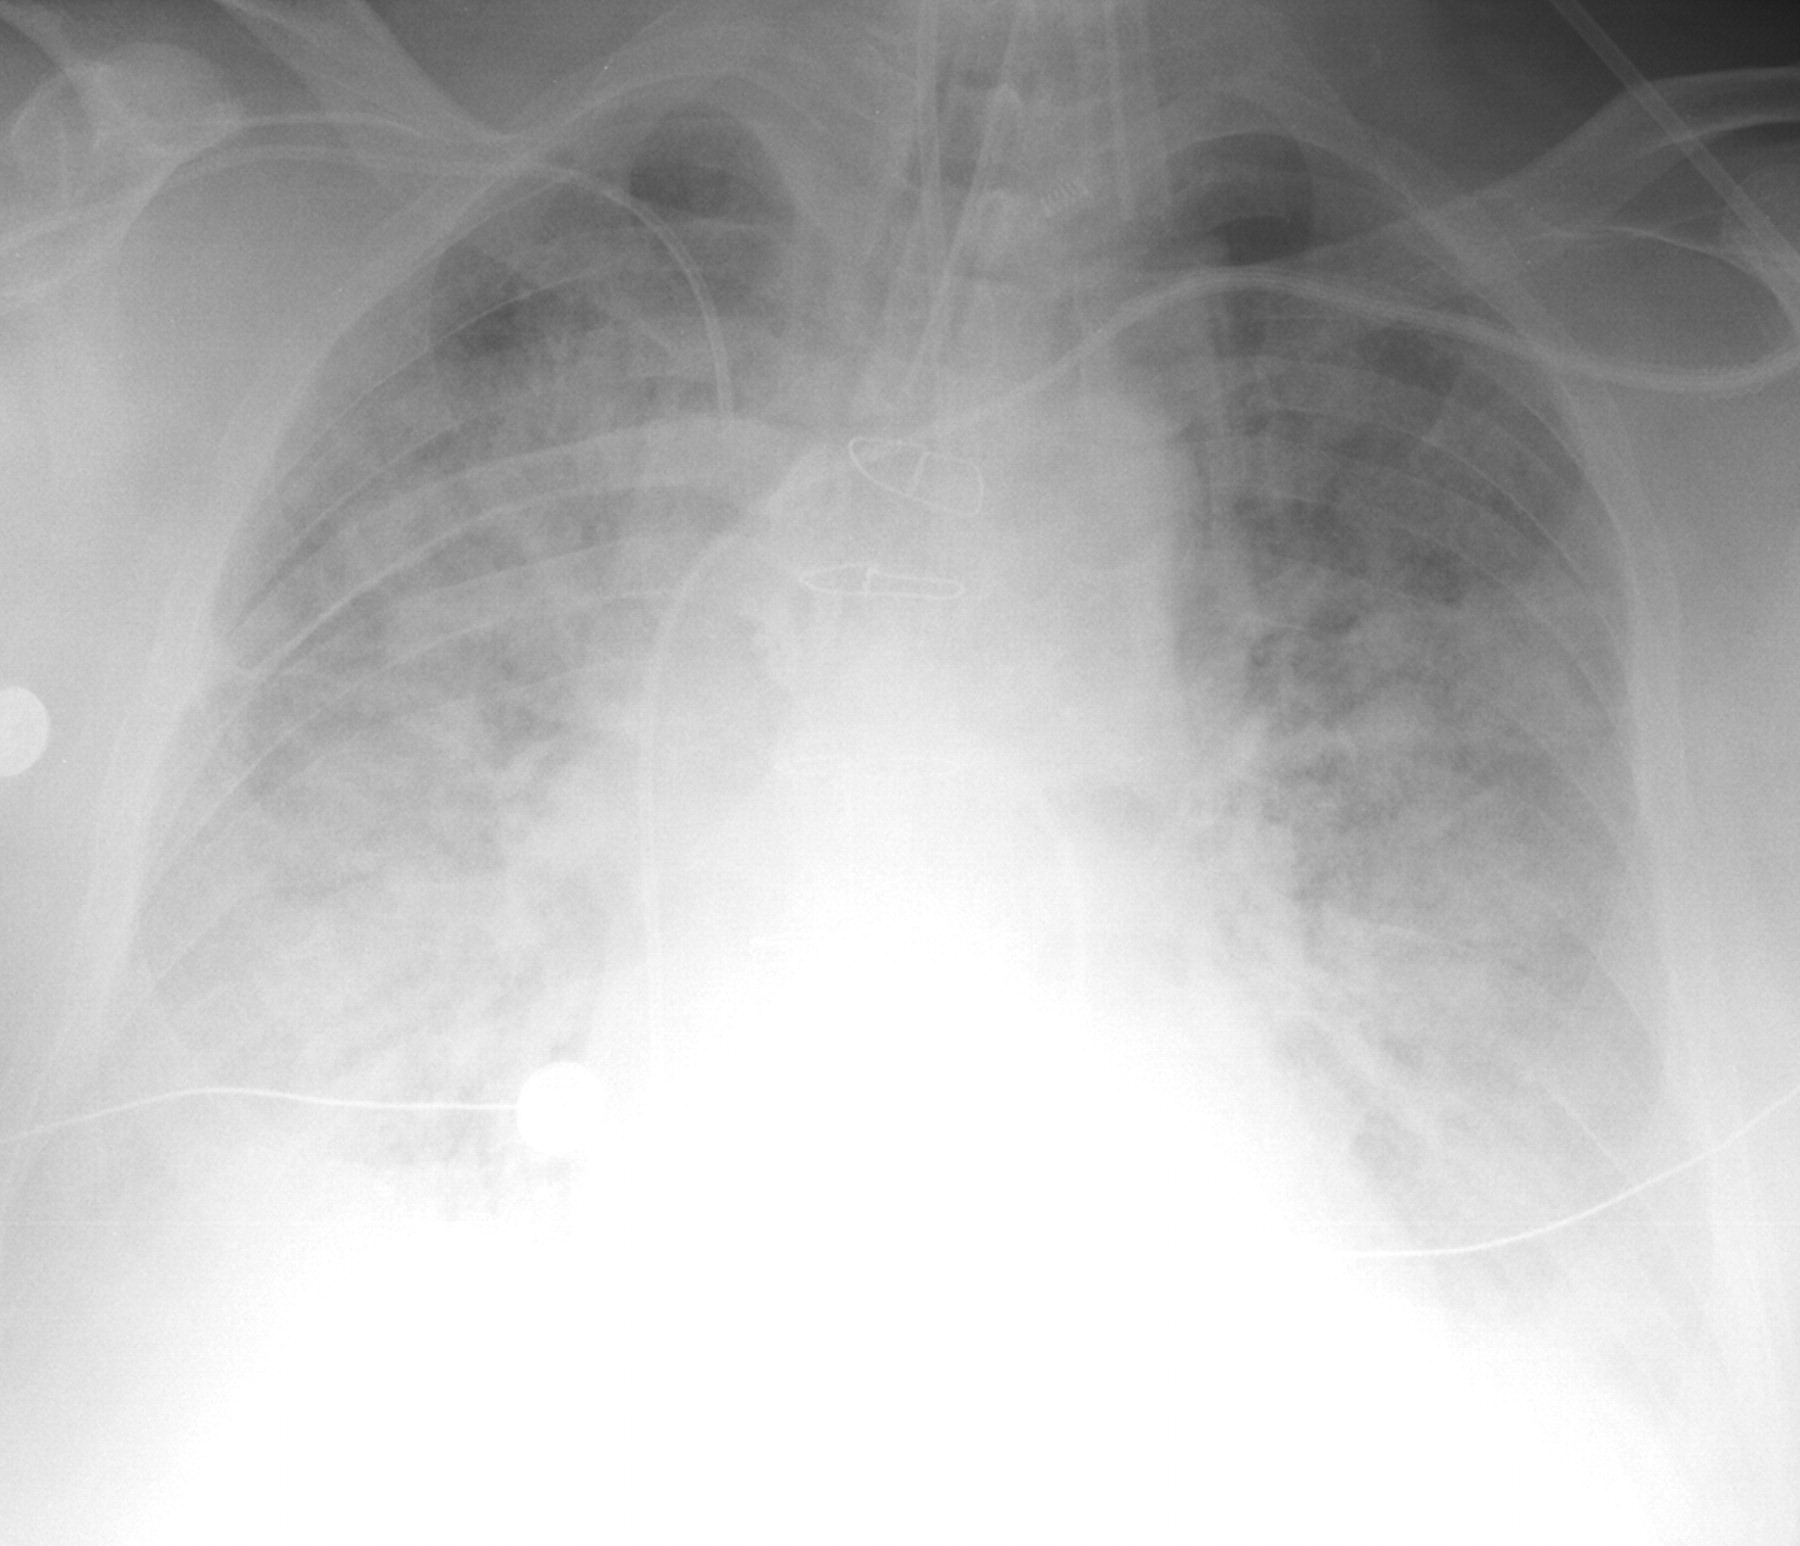

In [55]:
def test_single_image(pretrained_model,model,path):
  images = read_image(path)
  time.sleep(.5)
  bt_prediction = pretrained_model.predict(images)
  preds = model.predict(bt_prediction)
  for idx, animal, x in zip(range(0,3), class_labels , preds[0]):
   print("ID: {}, Label: {} {}%".format(idx, animal, round(x*100,2) ))
  print('Final Decision:')
  time.sleep(.5)
  for x in range(3):
   print('.'*(x+1))
   time.sleep(.2)
  class_predicted = np.argmax(model.predict(bt_prediction), axis=-1)
  class_dictionary = generator_test.class_indices
  inv_map = {v: k for k, v in class_dictionary.items()}
  print("ID: {}, Label: {}".format(class_predicted[0],  inv_map[class_predicted[0]]))
  return load_img(path)
path = r'/content/drive/MyDrive/Vani-dev/xray_dataset_covid19/test/COVID/SARS-10.1148rg.242035193-g04mr34g0-Fig8c-day10.jpeg'
test_single_image(pretrained_model_googleNet,model_googleNet,path)